<a href="https://colab.research.google.com/github/Infraking/Financial-Fraud-Detection-System/blob/main/04_Evaluation_Visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4: Random Forest Evaluation Visualizations

### Objective

The objective of this notebook is to evaluate the trained Random Forest model using graphical performance metrics. The notebook generates the Confusion Matrix, ROC Curve, and Precision-Recall Curve for fraud detection analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

## Step 1: Extract the Dataset

Extract the ZIP file before loading the dataset.

In [2]:
with zipfile.ZipFile("/content/PS_20174392719_1491204439457_log.csv.zip","r") as zip_ref:
    zip_ref.extractall("/content")

## Step 2: Load the Dataset

Load the extracted dataset into a Pandas DataFrame.

In [3]:
df = pd.read_csv("/content/PS_20174392719_1491204439457_log.csv")

## Step 3: Create a Sample Dataset

A representative sample is selected to reduce computation time while maintaining reliable model evaluation.

In [4]:
sample_df = df.sample(n=200000, random_state=42)

## Step 4: Prepare Features and Target

Separate the feature variables and the target variable for model training.

In [5]:
X = sample_df.drop("isFraud", axis=1)
y = sample_df["isFraud"]

## Step 5: Encode Categorical Features

Convert categorical variables into numerical values using Label Encoding.

In [6]:
for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

## Step 6: Split the Dataset

Split the dataset into training and testing subsets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Step 7: Train the Random Forest Model

Initialize and train the Random Forest classifier.

In [8]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)

## Step 8: Generate Predictions

Predict fraud labels and probability scores for the test dataset.

In [9]:
preds = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:,1]

## Step 9: Confusion Matrix

Visualize the confusion matrix to compare predicted and actual classes.

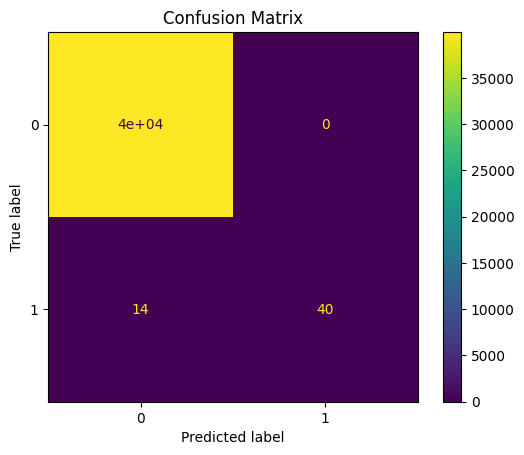

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)

plt.title("Confusion Matrix")

plt.show()

## Step 10: ROC Curve

Plot the Receiver Operating Characteristic (ROC) curve to evaluate the model's discrimination ability.

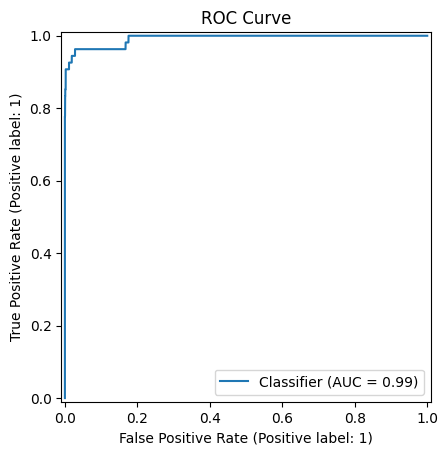

In [11]:
RocCurveDisplay.from_predictions(y_test, probs)

plt.title("ROC Curve")

plt.show()

## Step 11: Precision-Recall Curve

Plot the Precision-Recall Curve to evaluate fraud detection performance on the imbalanced dataset.

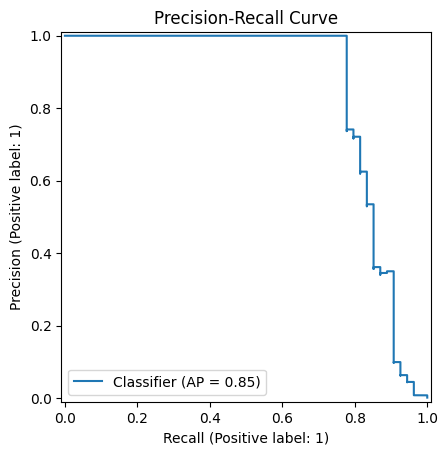

In [12]:
PrecisionRecallDisplay.from_predictions(y_test, probs)

plt.title("Precision-Recall Curve")

plt.show()

## Conclusion

The Random Forest model was successfully evaluated using graphical performance metrics. The Confusion Matrix, ROC Curve, and Precision-Recall Curve provide insights into the model's fraud detection capability and overall classification performance.